# Python for (open) Neuroscience  
### Practical 2.5 — *Plotting*
#### Module 02 - Scientific Stack

**How to use this notebook**
- Complete the `____` blanks.
- Keep the starter code structure whenever possible.

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_theme(style='whitegrid')

## Load the data

Use the CSV files if they are in the same folder as this notebook.

In [5]:
subjects = pd.read_csv("data" / Path("subjects.csv"))
trials = pd.read_csv("data" / Path("trials.csv"))
subject_summary = pd.read_csv("data" / Path("subject_summary.csv"))
erp = pd.read_csv("data" / Path("erp_timecourse.csv"))
roi = pd.read_csv("data" / Path("roi_activation.csv"))

subjects.head()


,subject,group,age,sex,handedness,sleep_hours,caffeine_mg,bdi_score,stai_state,notes
0,S01,mci,38,M,right,6.3,159,12,31,elevated memory complaints
1,S02,control,20,F,right,7.9,0,11,41,healthy volunteer
2,S03,mci,33,F,right,6.2,117,8,51,elevated memory complaints
3,S04,control,22,F,right,8.0,69,2,21,healthy volunteer
4,S05,control,24,F,right,7.5,47,11,30,healthy volunteer


## Exercise 1 — Histogram of reaction times

Plot a histogram of trial-level reaction times (`rt_ms`) from `trials`. Add an informative title and axis labels.

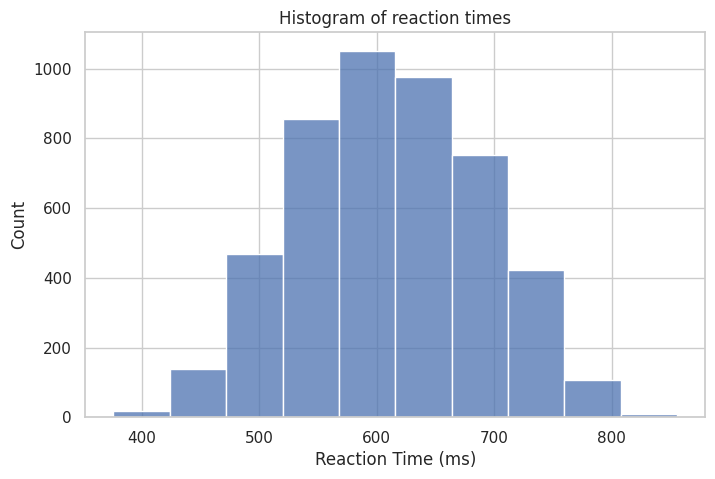

In [10]:
# Your code here
plt.figure()
sns.histplot(data=trials, x=trials["rt_ms"], bins=10)
plt.title("Histogram of reaction times")
plt.xlabel(f"Reaction Time (ms)")
plt.ylabel(f"Count")
plt.show()


## Exercise 2 — Compare RT distributions across conditions

Create a boxplot of `rt_ms` by `group`. Then overlay individual observations with a stripplot using a small alpha.

**New function:** `sns.stripplot()` overlays individual points on top of summary plots such as boxplots.

In [ ]:
# merge subjects with trials
merged_df = pd.merge(trials, subjects, on=True)

# Starter code
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x=____, y=____)
sns.stripplot(data=____, x=____, y=____, alpha=____, jitter=True)
plt.title(____)
plt.show()


## Exercise 3 — Accuracy by group

Use `subject_summary` to create a barplot of mean accuracy by `group`, with error bars.

**New function:** In recent seaborn versions, `errorbar='sd'` or `errorbar=('ci', 95)` controls the uncertainty bars.

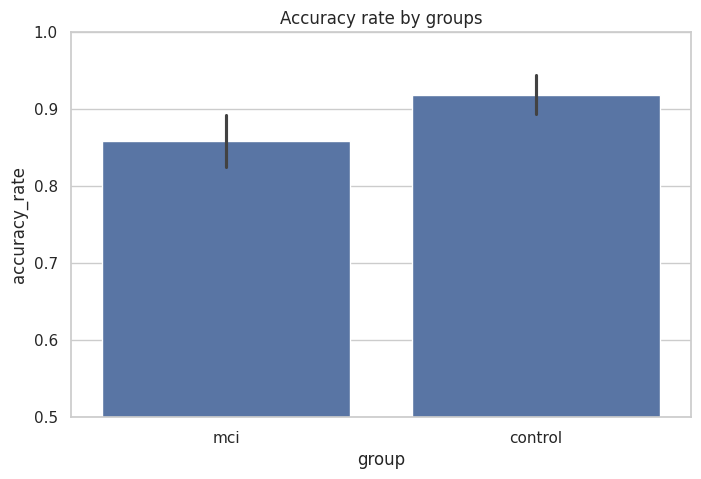

In [ ]:
# Hint: accuracy column is `accuracy_rate`
plt.figure()
sns.barplot(data=subject_summary, x=subject_summary["group"], y=subject_summary["accuracy_rate"], errorbar='sd')
plt.title("Mean Accuracy Rate by Groups")
plt.ylim(0.5, 1)
plt.show()


## Exercise 4 — Scatterplot with regression line

Plot `mean_rt_ms` against `working_memory_score` from `subject_summary`, color points by `group`, and add a regression line.

**New function or concept:** `sns.regplot()` can add a fitted regression line. Here we disable its own scatter points with `scatter=False`.

In [ ]:
plt.figure()
sns.scatterplot(data=subject_summary, x=subject_summary["mean_rt_ms"], y=subject_summary["working_memory_score"], hue=____)
sns.regplot(data=subject_summary, x=subject_summary["mean_rt_ms"], y=____, scatter=False)
plt.title(____)
plt.show()


## Exercise 5 — Select and plot only correct trials

Filter `trials` to keep only correct responses, then create a violin plot of `rt_ms` by `condition`.

In [ ]:
# Step 1: filter
correct_trials = trials[trials["condition"] == "congruent"]

# Step 2: plot
plt.figure()
sns.violinplot(data=correct_trials, x=, y=____)
plt.title(____)
plt.show()


## Exercise 6 — Facet plots across groups

Using subject_summary, create separate scatterplots of `accuracy_rate` vs `mean_rt_ms` for each `group` using seaborn's faceting system.

**New function:** `sns.relplot()` is a figure-level function that can create faceted plots across rows or columns.

In [ ]:
g = sns.relplot(
    data=____,
    x=____,
    y=____,
    col=____,
    hue=____,
)
g.fig.suptitle(____)
g.fig.subplots_adjust(top=0.85)
plt.show()


## Exercise 7 — Grouped summary with pandas then plot

Compute the mean reaction time by `group` and `condition` using pandas, reset the index, then plot the result with seaborn. Use the `merged_df` you created earlier.

**New function:** `reset_index()` converts grouped index levels back into normal columns so seaborn can use them easily.

In [ ]:
summary = (
    merged_df
    .groupby([____, ____])[____]
    .mean()
    .reset_index()
)

summary

plt.figure()
sns.barplot(data=____, x=____, y=____, hue=____)
plt.title(____)
plt.show()


## Exercise 8 — Time-course plot of ERP waveforms

Plot ERP amplitude over time for each condition using `erp_timecourse`. Use `time_ms` on the x-axis and `amplitude_uv` on the y-axis.

In [ ]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=____, x=____, y=____, hue=____)
plt.axvline(0, linestyle='--')
plt.axhline(0, linestyle=':')
plt.title(____)
plt.xlabel(____)
plt.ylabel(____)
plt.show()


## Exercise 9 — ERP plot by condition and group

Extend the previous exercise by creating one ERP panel per group.

In [ ]:
g = sns.relplot(
    data=____,
    kind="line",
    x=____,
    y=____,
    hue=____,
    col=____,
    height=4,
    aspect=1.2
)
g.fig.suptitle(____)
g.fig.subplots_adjust(top=0.85)
plt.show()


## Exercise 10 — ROI activation heatmap

Pivot the ROI activation table so rows are ROIs, columns are contrasts, and values are `beta_weight`. Then plot a heatmap.

 Use `pivot_table()` to derive the data matrix, which is useful for heatmaps.

In [ ]:
heatmap_data = roi.pivot_table(index=____, columns=____, values=____, aggfunc = "mean")

heatmap_data

plt.figure(figsize=(7, 5))
sns.heatmap(____, annot=True, cmap=____)
plt.title(____)
plt.show()


## Exercise 11 — Find the slowest participants

Sort `subject_summary` by `mean_rt_ms`, take the 10 slowest participants, and create a horizontal barplot.

**New function:** A horizontal barplot is often clearer when labels or IDs are shown on the y-axis.

In [ ]:
slowest = (
    subject_summary
    .sort_values(by=____, ascending=____)
    .head(____)
)

plt.figure(figsize=(8, 6))
sns.barplot(data=____, x=____, y=____, orient="h")
plt.title(____)
plt.show()


## Exercise 12 — Multi-panel figure with matplotlib

Create a 2x2 figure with: histogram of `age`, countplot of `group`, scatterplot of `accuracy_rate` vs `mean_rt_ms`, and boxplot of `pupil_baseline_mm` by `group`.

**New function:** `plt.subplots()` creates a grid of axes so you can build multi-panel figures.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(data=____, x=____, ax=axes[0, 0])
sns.countplot(data=____, x=____, ax=axes[0, 1])
sns.scatterplot(data=____, x=____, y=____, ax=axes[1, 0])
sns.boxplot(data=____, x=____, y=____, ax=axes[1, 1])

axes[0, 0].set_title(____)
axes[0, 1].set_title(____)
axes[1, 0].set_title(____)
axes[1, 1].set_title(____)

plt.tight_layout()
plt.show()


## Exercise 13 — Correlation heatmap from selected variables

Select a subset of numerical columns from `subject_summary`, compute the correlation matrix, and visualize it.

**New function:** `.corr()` computes pairwise correlations between numerical columns.

In [ ]:
cols = [____, ____, ____, ____]
corr = subject_summary[cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap=____)
plt.title(____)
plt.show()


## Exercise 14 — Condition effect within each subject

From `trials`, compute each subject's mean RT separately for each condition, reshape so the conditions are separate columns, and make a scatterplot comparing them.

**New function or concept:** This combines `groupby()` with `pivot()` to move from long format to wide format for subject-wise comparisons.

In [ ]:
subject_condition = (
    trials
    .groupby([____, ____])[____]
    .mean()
    .reset_index()
)

wide = subject_condition.pivot(index=____, columns=____, values=____)
wide = wide.reset_index()

wide.head()

plt.figure()
sns.scatterplot(data=____, x=____, y=____)
plt.plot([wide.iloc[:,1].min(), wide.iloc[:,1].max()],
         [wide.iloc[:,1].min(), wide.iloc[:,1].max()],
         linestyle='--')
plt.title(____)
plt.show()
